### 1. Импорт необходимых библиотек

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Загрузка данных

In [68]:
df = pd.read_csv('data_01_socio.csv', sep=';')#, encoding='KOI8-R')
#df.head

### 3. Анализ данных

#### 3.1 Общий анализ дата фрейма

In [69]:
df.info() #Информация о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76777 entries, 0 to 76776
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   section          76777 non-null  object 
 1   indicator_code   76777 non-null  object 
 2   indicator_name   76777 non-null  object 
 3   subsection       76777 non-null  object 
 4   object_name      76777 non-null  object 
 5   object_level     76777 non-null  object 
 6   object_oktmo     76777 non-null  int64  
 7   object_okato     76777 non-null  int64  
 8   year             76777 non-null  int64  
 9   indicator_value  76777 non-null  float64
 10  indicator_unit   76777 non-null  object 
 11  comment          76777 non-null  object 
 12  source           76777 non-null  object 
 13  version_date     76777 non-null  object 
dtypes: float64(1), int64(3), object(10)
memory usage: 8.2+ MB


In [70]:
df.head() #Первые 5 строк данных

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source,version_date
0,Население,Y477110050,Возрастной состав населения: Население в трудо...,CD,Алтайский край,Регион,1000000,1000000,2001,61.4,"Оценка на конец года, в процентах от общей чис...","2000‒2018 гг. — мужчины в возрасте 16‒59 лет, ...",Регионы России. Социально-экономические показа...,v20260313
1,Население,Y477110050,Возрастной состав населения: Население в трудо...,CD,Алтайский край,Регион,1000000,1000000,2002,62.1,"Оценка на конец года, в процентах от общей чис...","2000‒2018 гг. — мужчины в возрасте 16‒59 лет, ...",Регионы России. Социально-экономические показа...,v20260313
2,Население,Y477110050,Возрастной состав населения: Население в трудо...,CD,Алтайский край,Регион,1000000,1000000,2003,62.7,"Оценка на конец года, в процентах от общей чис...","2000‒2018 гг. — мужчины в возрасте 16‒59 лет, ...",Регионы России. Социально-экономические показа...,v20260313
3,Население,Y477110050,Возрастной состав населения: Население в трудо...,CD,Алтайский край,Регион,1000000,1000000,2004,63.1,"Оценка на конец года, в процентах от общей чис...","2000‒2018 гг. — мужчины в возрасте 16‒59 лет, ...",Регионы России. Социально-экономические показа...,v20260313
4,Население,Y477110050,Возрастной состав населения: Население в трудо...,CD,Алтайский край,Регион,1000000,1000000,2005,63.2,"Оценка на конец года, в процентах от общей чис...","2000‒2018 гг. — мужчины в возрасте 16‒59 лет, ...",Регионы России. Социально-экономические показа...,v20260313


#### 3.2 Подготовка дата фрейма для дальнейшего анализа

In [71]:
df_new = df.drop(['section', 
                  'subsection', 
                  'object_oktmo', 
                  'object_okato', 
                  'comment', 
                  'source', 
                  'version_date'], 
                 axis=1) #убирем ненужные столбцы
#df_new.head

In [72]:
print(df_new.duplicated().sum()) #Проверка на дубликаты
print(df_new.isnull().sum()) #Проверка на пропуски

0
indicator_code     0
indicator_name     0
object_name        0
object_level       0
year               0
indicator_value    0
indicator_unit     0
dtype: int64


In [73]:
print(df_new['indicator_name'].unique()) #выбираем переменные для дальнейшего анализа

['Возрастной состав населения: Население в трудоспособном возрасте'
 'Возрастной состав населения: Население моложе трудоспособного возраста'
 'Возрастной состав населения: Население старше трудоспособного возраста'
 'Коэффициенты демографической нагрузки: Всего'
 'Коэффициенты демографической нагрузки: Моложе трудоспособного возраста'
 'Коэффициенты демографической нагрузки: Старше трудоспособного возраста'
 'Коэффициенты естественного прироста населения на 1000 человек населения'
 'Коэффициенты миграционного прироста на 10000 человек населения'
 'Коэффициенты младенческой смертности'
 'Общие коэффициенты брачности на 1000 человек населения'
 'Общие коэффициенты разводимости на 1000 человек населения'
 'Общие коэффициенты рождаемости' 'Общие коэффициенты смертности'
 'Ожидаемая продолжительность жизни при рождении: Все население'
 'Ожидаемая продолжительность жизни при рождении: Женщины'
 'Ожидаемая продолжительность жизни при рождении: Мужчины'
 'Распределение числа выбывших по напра

In [74]:
# Анализировать будем три показателя:
#   -'Численность населения'
#   -'Удельный вес городского населения в общей численности населения'
#   -'Удельный вес сельского населения в общей численности населения'

In [75]:
df_new_3_indicator = df_new[(df_new['indicator_name'] == 'Численность населения') |
                             (df_new['indicator_name'] == 'Удельный вес городского населения в общей численности населения') |
                             (df_new['indicator_name'] == 'Удельный вес сельского населения в общей численности населения')
                            ].copy() # создаем отдельный дата фрейм с необходимыми показателями
#df_new_3_indicator.head

#### 3.3 Проверка дата фрейма на пропуски и дубликаты

In [76]:
print(df_new_3_indicator.duplicated().sum()) #Проверка на дубликаты
print(df_new_3_indicator.isnull().sum()) #Проверка на пропуски

0
indicator_code     0
indicator_name     0
object_name        0
object_level       0
year               0
indicator_value    0
indicator_unit     0
dtype: int64


#### 3.4 Поиск аномалий (выбросов)

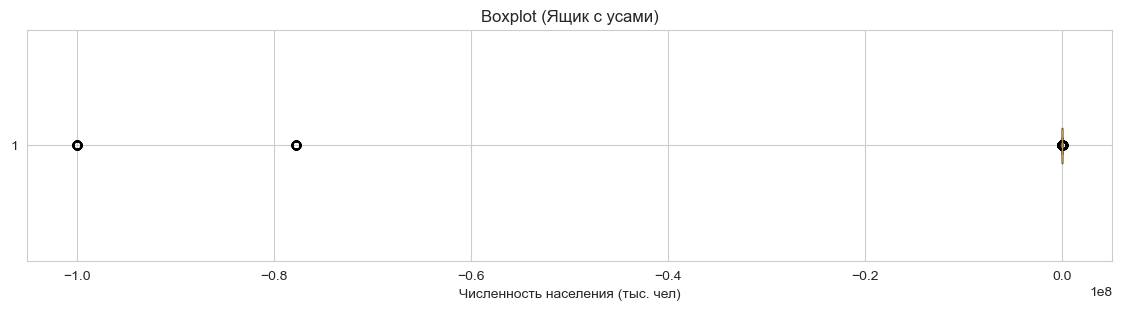

In [77]:
fig, ax = plt.subplots(figsize=(14, 3)) #рисуем график типа ящик с усами для того чтобы проверить выбросы
ax.boxplot(df_new_3_indicator['indicator_value'], vert=False)
ax.set_xlabel('Численность населения (тыс. чел)')
ax.set_title('Boxplot (Ящик с усами)')
plt.show()

In [78]:
# на графике Ящик с усами видим выбросы меньше нуля
# так как показатель численность населения и удельный вес не может быть меньше нуля будем чистить эти показатели
# но сначала проанализируем их

In [79]:
below_0 = df_new_3_indicator[df_new_3_indicator['indicator_value'] < 0] #фильтруем показатели меньше нуля
print(below_0[['object_name', 'year', 'indicator_value']].head(30))

           object_name  year  indicator_value
64506  Республика Крым  2001      -99999999.0
64507  Республика Крым  2002      -99999999.0
64508  Республика Крым  2003      -99999999.0
64509  Республика Крым  2004      -99999999.0
64510  Республика Крым  2005      -99999999.0
64511  Республика Крым  2006      -99999999.0
64512  Республика Крым  2007      -99999999.0
64513  Республика Крым  2008      -99999999.0
64514  Республика Крым  2009      -99999999.0
64515  Республика Крым  2010      -99999999.0
64516  Республика Крым  2011      -99999999.0
64517  Республика Крым  2012      -99999999.0
64518  Республика Крым  2013      -99999999.0
64874      Севастополь  2001      -99999999.0
64875      Севастополь  2002      -99999999.0
64876      Севастополь  2003      -99999999.0
64877      Севастополь  2004      -99999999.0
64878      Севастополь  2005      -99999999.0
64879      Севастополь  2006      -99999999.0
64880      Севастополь  2007      -99999999.0
64881      Севастополь  2008      

In [80]:
pivot = below_0.pivot_table(values='indicator_value',index='year',columns='object_name',aggfunc='count')
# смотрим по каким годам и по каким регионам отрицательные значения в данных
print(pivot)

object_name  Москва  Республика Крым  Санкт-Петербург  Севастополь
year                                                              
2001            1.0              3.0              1.0          3.0
2002            1.0              3.0              1.0          3.0
2003            1.0              3.0              1.0          3.0
2004            1.0              3.0              1.0          3.0
2005            1.0              3.0              1.0          3.0
2006            1.0              3.0              1.0          3.0
2007            1.0              3.0              1.0          3.0
2008            1.0              3.0              1.0          3.0
2009            1.0              3.0              1.0          3.0
2010            1.0              3.0              1.0          3.0
2011            1.0              3.0              1.0          3.0
2012            1.0              3.0              1.0          3.0
2013            1.0              3.0              1.0         

In [81]:
# По регионам Крым и Севастополь видим отрицательные данные по всем трём показателям до 2014 г.
# а регион Москва и Санкт-Петербург необходимо посмотреть более подробно

In [82]:
pivot_MSK_SPB = below_0[(below_0['object_name'] == 'Москва') | (below_0['object_name'] == 'Санкт-Петербург')].copy()
pivot_MSK_SPB = pivot_MSK_SPB.pivot_table(values='indicator_value',index='indicator_name',columns='object_name',aggfunc='count')
# смотрим по каким показателям В регионе Москва и Санкт-Петербург отрицательные значения
print(pivot_MSK_SPB)

object_name                                         Москва  Санкт-Петербург
indicator_name                                                             
Удельный вес сельского населения в общей числен...      23               23


#### 3.5 Очистка дата фрейма от отрицательных значений

In [83]:
df_new_3_indicator_clean=df_new_3_indicator.copy()
df_new_3_indicator_clean['indicator_value'] = df_new_3_indicator_clean['indicator_value'].replace({
    -99999999.0: np.nan,
    -77777777.0: 0
}) # заменяем отрицательные значения на пустоту
df_new_3_indicator_clean = df_new_3_indicator_clean.dropna(subset=['indicator_value']).copy() #удаляем строки с пустыми значениями

In [84]:
below_0_2 = df_new_3_indicator_clean[df_new_3_indicator_clean['indicator_value'] < 0] #проверяем наличие отрицательных показателей
print(below_0_2[['object_name', 'year', 'indicator_value']].head(30))

Empty DataFrame
Columns: [object_name, year, indicator_value]
Index: []


### 4 Анализ показателя Численность населения

#### 4.1 Считаем количество регионов по показателю Численность населения

In [85]:
df_population = df_new_3_indicator_clean[ #фильтруем по показателю Численность населения и по уровню Регион
    (df_new_3_indicator_clean['indicator_name'] == 'Численность населения') & 
    (df_new_3_indicator_clean['object_level'] == 'Регион')
    ]
grouped = df_population.groupby('year')['indicator_value'].count() #группируем по году и выводим количество
print(grouped)

year
2001    85
2002    85
2003    85
2004    85
2005    85
2006    85
2007    85
2008    85
2009    85
2010    85
2011    87
2012    87
2013    87
2014    87
2015    87
2016    87
2017    87
2018    87
2019    87
2020    87
2021    87
2022    87
2023    87
Name: indicator_value, dtype: int64


In [86]:
# Делаем вывод что самый свежий год 2023 и данные по этому году есть по всем регионам

#### 4.2 Анализирем переменную Численность населения

In [87]:
df_population_2023 = df_population[df_population['year'] == 2023]
print(df_population_2023['indicator_value'].describe())

count       87.000000
mean      1736.088506
std       1893.845096
min         42.200000
25%        685.700000
50%       1121.400000
75%       2194.350000
max      13149.800000
Name: indicator_value, dtype: float64


In [88]:
# Делаем вывод что самый большой регион 13 млн. человек, самый маленький 42 тыс. человек, всего 87 регионов

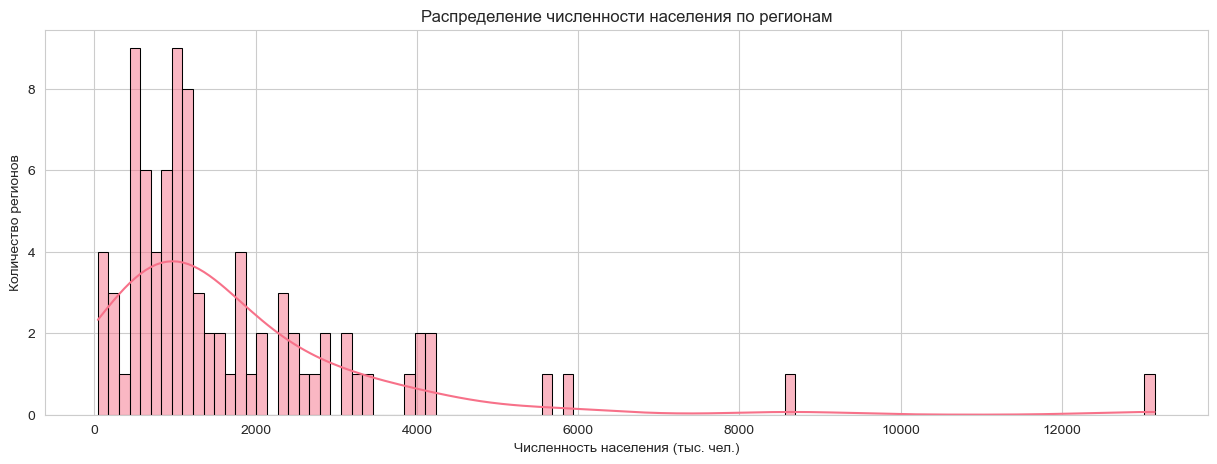

In [112]:
plt.figure(figsize=(15, 5)) # строим график (использованием библиотеки Seaborn)
sns.histplot(df_population_2023['indicator_value'], bins=100, edgecolor='black',kde=True)
plt.xlabel('Численность населения (тыс. чел.)')
plt.ylabel('Количество регионов')
plt.title('Распределение численности населения по регионам')
plt.grid(True)
plt.show()



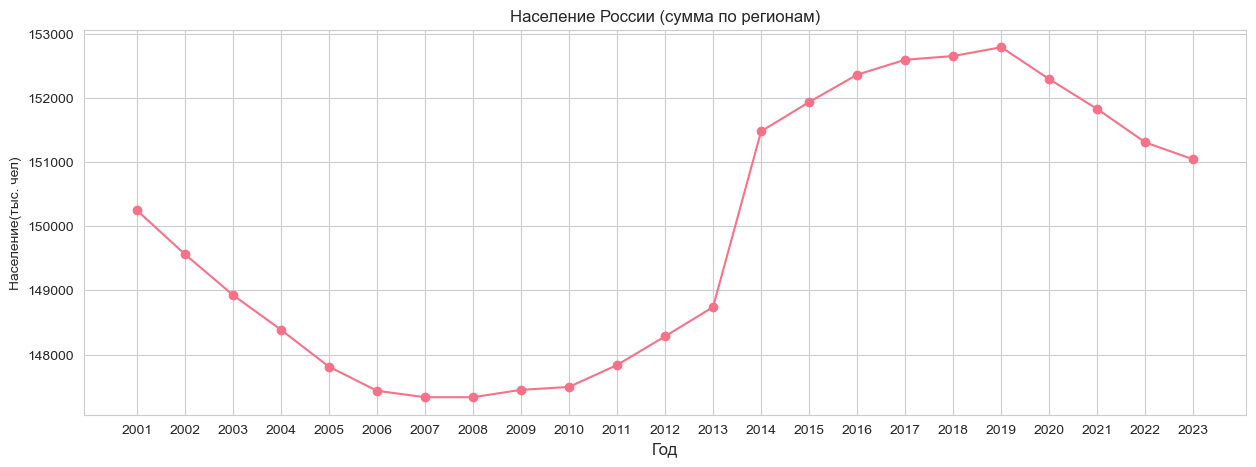

In [113]:
df_population_by_year = df_population.groupby('year')['indicator_value'].sum() 
#делаем группировку чтобы получить сумму населения регионов по годам

plt.figure(figsize=(15, 5)) # строим график
plt.plot(df_population_by_year.index, df_population_by_year.values, marker='o')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Население(тыс. чел)')
plt.title('Население России (сумма по регионам)')
plt.grid(True)
plt.xticks(df_population_by_year.index)
plt.show()

In [91]:
# На графике видим резкое увлечение численности населения в 14-м году скорее за счёт присоединение нового регионов

### 5 Анализирем переменные Удельный вес городского населения, сельского населения

In [92]:
#фильтруем по показателю Удельный вес городского населения, сельского населения и по уровню Регион
df_urban_rural = df_new_3_indicator_clean[ 
    ((df_new_3_indicator_clean['indicator_name'] == 'Удельный вес городского населения в общей численности населения') |
    (df_new_3_indicator_clean['indicator_name'] == 'Удельный вес сельского населения в общей численности населения')) &
    (df_new_3_indicator_clean['object_level'] == 'Регион')
    ]

In [93]:
pivot_urban_rural = df_urban_rural.pivot_table(
    index=['object_name', 'year', 'object_level'],
    columns='indicator_name',
    values='indicator_value'
).reset_index()

In [94]:
#pivot_urban_rural.head

In [95]:
# создаем дополнительный столбец и суммируем два показателя
pivot_urban_rural['sum'] = pivot_urban_rural['Удельный вес городского населения в общей численности населения'] + pivot_urban_rural['Удельный вес сельского населения в общей численности населения']

In [96]:
# фильтруем показатели неравные 100% то есть отклонения
pivot_urban_rural_filter = pivot_urban_rural[pivot_urban_rural['sum'] != 100]
pivot_urban_rural_filter.head # что значение отвечающих ся от 100 нет, значит всё хорошо

<bound method NDFrame.head of Empty DataFrame
Columns: [object_name, year, object_level, Удельный вес городского населения в общей численности населения, Удельный вес сельского населения в общей численности населения, sum]
Index: []>

### 6 Анализирем переменную Удельный вес городского населения

In [97]:
df_share_urban_2023 = df_new_3_indicator_clean[ #фильтруем по показателю Удельный вес городского населения, по уровню Регион, 2023 год
    (df_new_3_indicator_clean['indicator_name'] == 'Удельный вес городского населения в общей численности населения') & 
    (df_new_3_indicator_clean['object_level'] == 'Регион') & 
    (df_new_3_indicator_clean['year'] == 2023)
    ]
#grouped = df_population.groupby('year')['indicator_value'].count() #группируем по году и выводим количество
#print(grouped)
print(df_share_urban_2023['indicator_value'].describe())

count     87.000000
mean      71.195402
std       12.821438
min       30.600000
25%       64.450000
50%       72.700000
75%       78.300000
max      100.000000
Name: indicator_value, dtype: float64


In [98]:
# Делаем вывод что наименьшее количество городского населения равно 30% наибольшее 100%

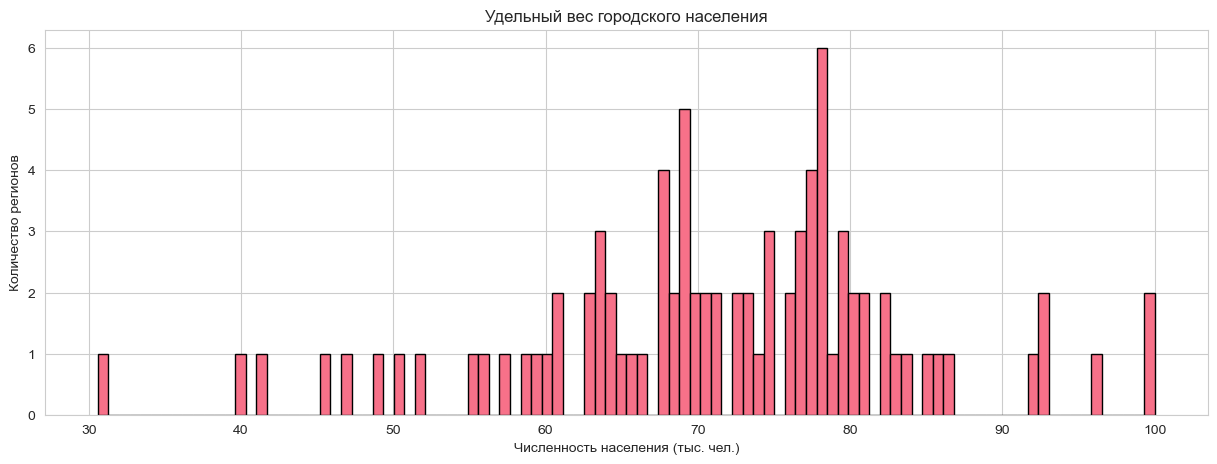

In [114]:
plt.figure(figsize=(15,5)) # строим график, где видим распределение регионов по уровню урбанизации
plt.hist(df_share_urban_2023['indicator_value'], bins=100, edgecolor='black')
plt.xlabel('Численность населения (тыс. чел.)')
plt.ylabel('Количество регионов')
plt.title('Удельный вес городского населения')
plt.show()

In [100]:
# выведем на экран лидеров по уровню городского и сельского населения
top_urban = df_share_urban_2023.sort_values('indicator_value', ascending=False).head(5)
print('Лидеры по уровню городского населения:')
print(top_urban[['object_name', 'indicator_value']])
print('Лидеры по уровню сельского населения:')
antitop_urban = df_share_urban_2023.sort_values('indicator_value', ascending=True).head(5)
print(antitop_urban[['object_name', 'indicator_value']])

Лидеры по уровню городского населения:
               object_name  indicator_value
63976               Москва            100.0
64804      Санкт-Петербург            100.0
63953  Магаданская область             96.5
64022   Мурманская область             93.0
64896          Севастополь             92.6
Лидеры по уровню сельского населения:
                           object_name  indicator_value
64344                 Республика Алтай             30.6
65333             Чеченская Республика             40.1
63723  Карачаево-Черкесская Республика             41.4
64413              Республика Дагестан             45.2
64459              Республика Калмыкия             47.0


### 7 Анализирем переменную Удельный вес городского населения и размера населения

In [101]:
#фильтруем по показателю Удельный вес городского населения, по уровню Регион, по 2023 году
df_urban = df_new_3_indicator_clean[ 
    (df_new_3_indicator_clean['indicator_name'] == 'Удельный вес городского населения в общей численности населения') &
    (df_new_3_indicator_clean['object_level'] == 'Регион') &
    (df_new_3_indicator_clean['year'] == 2023)
    ]
# переменную отфильтрованную по численности населения, региону, 2023 году df_population_2023 берём из кода выше

In [102]:
# Проверяем размер полученных таблиц перед объединением
print('Данных по численности')
print(f"Данных по численности: {len(df_population_2023)} записей")
print(f"Данных по урбанизации: {len(df_urban)} записей")
print(f"Регионов в данных по численности: {df_population_2023['object_name'].nunique()}")
print(f"Регионов в данных по урбанизации: {df_urban['object_name'].nunique()}")

Данных по численности
Данных по численности: 87 записей
Данных по урбанизации: 87 записей
Регионов в данных по численности: 87
Регионов в данных по урбанизации: 87


In [103]:
# объединяем 2 таблицы
merged = df_population_2023.merge(df_urban, on=['object_name'], how='inner')
# смотрим что получилось (дополнительно используя to_string чтоб не было переноса таблицы)
print(merged[['object_name', 'indicator_value_x', 'indicator_value_y']].sort_values('indicator_value_x', ascending=False).head(20)
    .to_string())

                                   object_name  indicator_value_x  indicator_value_y
30                                      Москва            13149.8              100.0
31                          Московская область             8651.3               78.0
23                          Краснодарский край             5833.0               57.3
64                             Санкт-Петербург             5597.8              100.0
67                        Свердловская область             4222.7               85.9
61                          Ростовская область             4152.5               67.8
46                     Республика Башкортостан             4064.3               62.6
58                        Республика Татарстан             4003.0               76.7
76  Тюменская область (с автономными округами)             3890.8               81.2
81                         Челябинская область             3395.8               82.5
48                         Республика Дагестан             3232.2

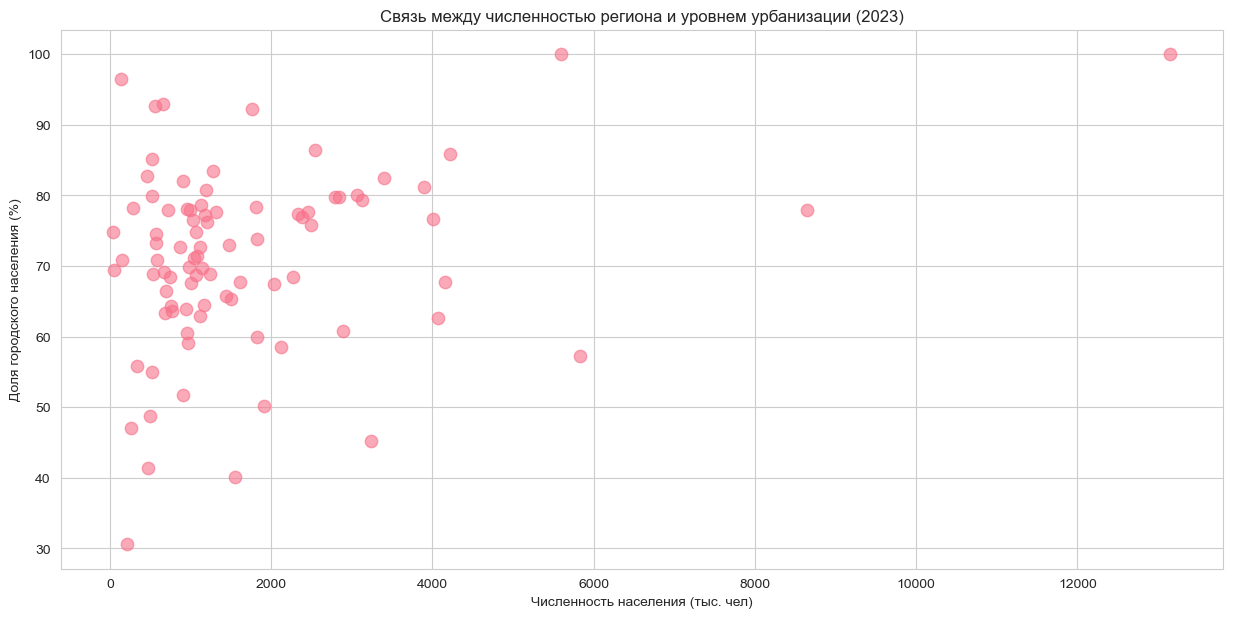

In [115]:
# строим диаграмму рассеяния
plt.figure(figsize=(15, 7))
plt.scatter(merged['indicator_value_x'], merged['indicator_value_y'], alpha=0.6, s=80)
plt.xlabel('Численность населения (тыс. чел)')
plt.ylabel('Доля городского населения (%)')
plt.title('Связь между численностью региона и уровнем урбанизации (2023)')
plt.grid(True)


In [105]:
#Выводы:
#   - чем крупнее регион по численности, тем выше доля городского населения.
#   - однако связь не идеальная — есть крупные регионы с высокой долей сельского населения